# # Text Preprocessing Pipeline for Toxic Comment Detection
# 
# **Objective:** Clean and prepare text data for machine learning models
# 
# **Steps:**
# 1. Text cleaning (lowercase, special chars, URLs, etc.)
# 2. Tokenization
# 3. Stopword removal
# 4. Lemmatization
# 5. Feature extraction (TF-IDF, n-grams)
# 6. Data splitting

## 1. Import Libraries

In [1]:
import pandas as pd
pd.__version__


'2.3.3'

In [2]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# NLP Libraries
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk import ngrams

# Sklearn
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split

# Download required NLTK data
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('omw-1.4', quiet=True)

# Warnings
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries loaded successfully!")


✅ Libraries loaded successfully!


## 2. Load Dataset

In [3]:
# Load the dataset
df = pd.read_csv('../youtoxic_english_1000.csv')

print(f"Dataset shape: {df.shape}")
print(f"Total comments: {len(df)}")

# Create binary target (at least one toxic label)
toxicity_labels = [
    'IsToxic', 'IsAbusive', 'IsThreat', 'IsProvocative', 
    'IsObscene', 'IsHatespeech', 'IsRacist', 'IsNationalist', 
    'IsSexist', 'IsHomophobic', 'IsReligiousHate', 'IsRadicalism'
]

df['is_toxic'] = df[toxicity_labels].any(axis=1).astype(int)

print(f"\nToxic: {df['is_toxic'].sum()} | Non-toxic: {(1-df['is_toxic']).sum()}")

# Display sample
display(df[['Text', 'is_toxic']].head())

Dataset shape: (1000, 15)
Total comments: 1000

Toxic: 462 | Non-toxic: 538


,Text,is_toxic
0,If only people would just take a step back and...,0
1,Law enforcement is not trained to shoot to app...,1
2,\nDont you reckon them 'black lives matter' ba...,1
3,There are a very large number of people who do...,0
4,"The Arab dude is absolutely right, he should h...",0


## 3. Text Cleaning Functions

In [4]:
class TextPreprocessor:
    """
    Comprehensive text preprocessing class for toxic comment detection
    """
    
    def __init__(self):
        self.lemmatizer = WordNetLemmatizer()
        self.stemmer = PorterStemmer()
        self.stop_words = set(stopwords.words('english'))
        
        # Keep some important words that might indicate toxicity
        self.stop_words -= {'not', 'no', 'nor', 'never', 'nothing', 
                           'nobody', 'nowhere', 'neither', 'without'}
    
    def clean_text(self, text):
        """Basic text cleaning"""
        if pd.isna(text):
            return ""
        
        # Convert to lowercase
        text = text.lower()
        
        # Remove URLs
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
        
        # Remove email addresses
        text = re.sub(r'\S+@\S+', '', text)
        
        # Remove mentions and hashtags (optional - might want to keep for context)
        # text = re.sub(r'@\w+|#\w+', '', text)
        
        # Remove HTML tags
        text = re.sub(r'<.*?>', '', text)
        
        # Remove numbers (optional - depends on use case)
        text = re.sub(r'\d+', '', text)
        
        # Remove extra whitespace
        text = re.sub(r'\s+', ' ', text).strip()
        
        return text
    
    def remove_punctuation(self, text):
        """Remove punctuation but keep sentence structure"""
        # Keep some punctuation that might indicate emotion (!?)
        # For toxic detection, repeated punctuation can be a signal
        return text.translate(str.maketrans('', '', string.punctuation))
    
    def remove_stopwords(self, text):
        """Remove stopwords while keeping negations"""
        words = text.split()
        filtered_words = [w for w in words if w not in self.stop_words]
        return ' '.join(filtered_words)
    
    def lemmatize_text(self, text):
        """Lemmatize words to their base form"""
        words = text.split()
        lemmatized = [self.lemmatizer.lemmatize(word) for word in words]
        return ' '.join(lemmatized)
    
    def stem_text(self, text):
        """Stem words (alternative to lemmatization)"""
        words = text.split()
        stemmed = [self.stemmer.stem(word) for word in words]
        return ' '.join(stemmed)
    
    def expand_contractions(self, text):
        """Expand common English contractions"""
        contractions_dict = {
            "ain't": "am not", "aren't": "are not", "can't": "cannot",
            "can't've": "cannot have", "could've": "could have",
            "couldn't": "could not", "didn't": "did not",
            "doesn't": "does not", "don't": "do not",
            "hadn't": "had not", "hasn't": "has not",
            "haven't": "have not", "he'd": "he would",
            "he'll": "he will", "he's": "he is",
            "i'd": "i would", "i'll": "i will",
            "i'm": "i am", "i've": "i have",
            "isn't": "is not", "it'd": "it would",
            "it'll": "it will", "it's": "it is",
            "let's": "let us", "mustn't": "must not",
            "shan't": "shall not", "she'd": "she would",
            "she'll": "she will", "she's": "she is",
            "shouldn't": "should not", "that's": "that is",
            "there's": "there is", "they'd": "they would",
            "they'll": "they will", "they're": "they are",
            "they've": "they have", "wasn't": "was not",
            "we'd": "we would", "we'll": "we will",
            "we're": "we are", "we've": "we have",
            "weren't": "were not", "what'll": "what will",
            "what're": "what are", "what's": "what is",
            "what've": "what have", "where's": "where is",
            "who'd": "who would", "who'll": "who will",
            "who're": "who are", "who's": "who is",
            "won't": "will not", "wouldn't": "would not",
            "you'd": "you would", "you'll": "you will",
            "you're": "you are", "you've": "you have"
        }
        
        # Create pattern for contractions
        contractions_pattern = re.compile('({})'.format('|'.join(contractions_dict.keys())),
                                         flags=re.IGNORECASE|re.DOTALL)
        
        def expand_match(contraction):
            match = contraction.group(0)
            expanded = contractions_dict.get(match.lower())
            return expanded if expanded else match
        
        expanded_text = contractions_pattern.sub(expand_match, text)
        return expanded_text
    
    def preprocess(self, text, remove_stopwords=True, use_lemmatization=True):
        """Complete preprocessing pipeline"""
        # Step 1: Expand contractions
        text = self.expand_contractions(text)
        
        # Step 2: Clean text
        text = self.clean_text(text)
        
        # Step 3: Remove punctuation
        text = self.remove_punctuation(text)
        
        # Step 4: Remove stopwords (optional)
        if remove_stopwords:
            text = self.remove_stopwords(text)
        
        # Step 5: Lemmatize or stem
        if use_lemmatization:
            text = self.lemmatize_text(text)
        else:
            text = self.stem_text(text)
        
        return text

# Initialize preprocessor
preprocessor = TextPreprocessor()

print("✅ Text Preprocessor initialized!")


✅ Text Preprocessor initialized!


## 4. Apply Preprocessing

In [5]:
# Test preprocessing on a sample
sample_text = df['Text'].iloc[0]
print("Original text:")
print(sample_text)
print("\n" + "="*80 + "\n")

print("Preprocessed text:")
preprocessed = preprocessor.preprocess(sample_text)
print(preprocessed)

Original text:
If only people would just take a step back and not make this case about them, because it wasn't about anyone except the two people in that situation.  To lump yourself into this mess and take matters into your own hands makes these kinds of protests selfish and without rational thought and investigation.  The guy in this video is heavily emotional and hyped up and wants to be heard, and when he gets heard he just presses more and more.  He was never out to have a reasonable discussion.  Kudos to the Smerconish for keeping level the whole time and letting Masri make himself out to be a fool.  How dare he and those that tore that city down in protest make this about themselves and to dishonor the entire incident with their own hate.  By the way, since when did police brutality become an epidemic?  I wish everyone would just stop pretending like they were there and they knew EXACTLY what was going on, because there's no measurable amount of people that honestly witnessed th

In [6]:
# Apply preprocessing to entire dataset
print("Preprocessing all comments... This may take a moment.")

df['text_cleaned'] = df['Text'].apply(lambda x: preprocessor.preprocess(x))

print("✅ Preprocessing complete!")
print(f"\nSample results:")
display(df[['Text', 'text_cleaned', 'is_toxic']].head(10))

Preprocessing all comments... This may take a moment.
✅ Preprocessing complete!

Sample results:


,Text,text_cleaned,is_toxic
0,If only people would just take a step back and...,people would take step back not make case not ...,0
1,Law enforcement is not trained to shoot to app...,law enforcement not trained shoot apprehend tr...,1
2,\nDont you reckon them 'black lives matter' ba...,dont reckon black life matter banner held whit...,1
3,There are a very large number of people who do...,large number people not like police officer ca...,0
4,"The Arab dude is absolutely right, he should h...",arab dude absolutely right not shot extra time...,0
5,here people his facebook is https://www.facebo...,people facebook tie isi terrorist group muslim...,1
6,"Check out this you tube post. ""Black man goes ...",check tube post black man go epic rant ferguso...,1
7,I would LOVE to see this pussy go to Staten Is...,would love see pussy go staten island spit cop...,1
8,I agree with the protestor.,agree protestor,0
9,mike browns father was made to say that boooshit,mike brown father made say boooshit,1


In [7]:
# Check for empty texts after preprocessing
empty_texts = df[df['text_cleaned'].str.strip() == ''].shape[0]
print(f"\n⚠️  Empty texts after preprocessing: {empty_texts}")

if empty_texts > 0:
    print("Removing empty texts...")
    df = df[df['text_cleaned'].str.strip() != ''].reset_index(drop=True)
    print(f"✅ Dataset shape after cleaning: {df.shape}")


⚠️  Empty texts after preprocessing: 0


## 5. Text Statistics After Preprocessing

In [8]:
# Calculate new text lengths
df['cleaned_length'] = df['text_cleaned'].str.len()
df['cleaned_word_count'] = df['text_cleaned'].str.split().str.len()

print("📊 Text Statistics After Preprocessing:")
print(f"Average text length: {df['cleaned_length'].mean():.2f} characters")
print(f"Average word count: {df['cleaned_word_count'].mean():.2f} words")

# Compare before and after
original_avg = df['Text'].str.len().mean()
cleaned_avg = df['cleaned_length'].mean()
reduction = ((original_avg - cleaned_avg) / original_avg) * 100

print(f"\nText length reduction: {reduction:.2f}%")

📊 Text Statistics After Preprocessing:
Average text length: 113.28 characters
Average word count: 17.58 words

Text length reduction: 38.95%


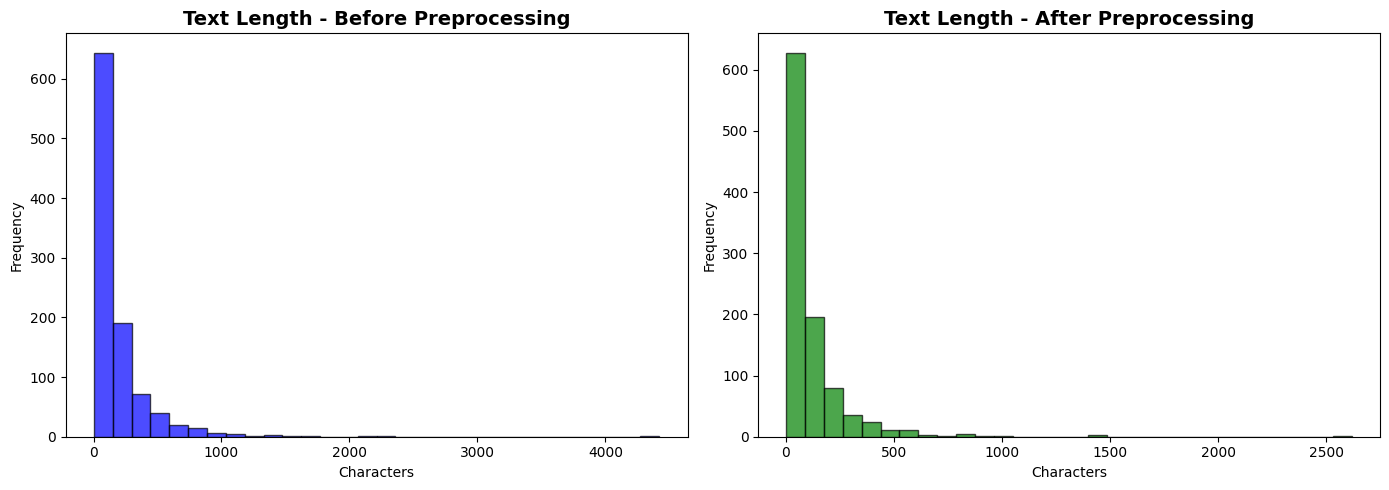

In [9]:
# Visualize text length distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before preprocessing
axes[0].hist(df['Text'].str.len(), bins=30, alpha=0.7, color='blue', edgecolor='black')
axes[0].set_title('Text Length - Before Preprocessing', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Characters')
axes[0].set_ylabel('Frequency')

# After preprocessing
axes[1].hist(df['cleaned_length'], bins=30, alpha=0.7, color='green', edgecolor='black')
axes[1].set_title('Text Length - After Preprocessing', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Characters')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## 6. Most Common Words Analysis

In [10]:
# Get all words from toxic and non-toxic comments
toxic_words = ' '.join(df[df['is_toxic']==1]['text_cleaned']).split()
non_toxic_words = ' '.join(df[df['is_toxic']==0]['text_cleaned']).split()

# Count frequencies
toxic_freq = Counter(toxic_words)
non_toxic_freq = Counter(non_toxic_words)

print("🔴 Top 20 words in TOXIC comments:")
for word, count in toxic_freq.most_common(20):
    print(f"  {word}: {count}")

print("\n🟢 Top 20 words in NON-TOXIC comments:")
for word, count in non_toxic_freq.most_common(20):
    print(f"  {word}: {count}")

🔴 Top 20 words in TOXIC comments:
  not: 176
  black: 161
  people: 130
  white: 94
  get: 89
  like: 75
  police: 72
  would: 71
  cop: 71
  brown: 59
  fuck: 59
  no: 58
  shot: 52
  shit: 45
  officer: 45
  guy: 43
  one: 40
  u: 38
  racist: 37
  man: 36

🟢 Top 20 words in NON-TOXIC comments:
  not: 246
  black: 140
  people: 130
  police: 103
  cop: 83
  like: 77
  officer: 74
  get: 72
  would: 71
  white: 69
  video: 67
  no: 66
  brown: 58
  shot: 54
  one: 49
  know: 48
  time: 45
  need: 38
  say: 36
  guy: 35


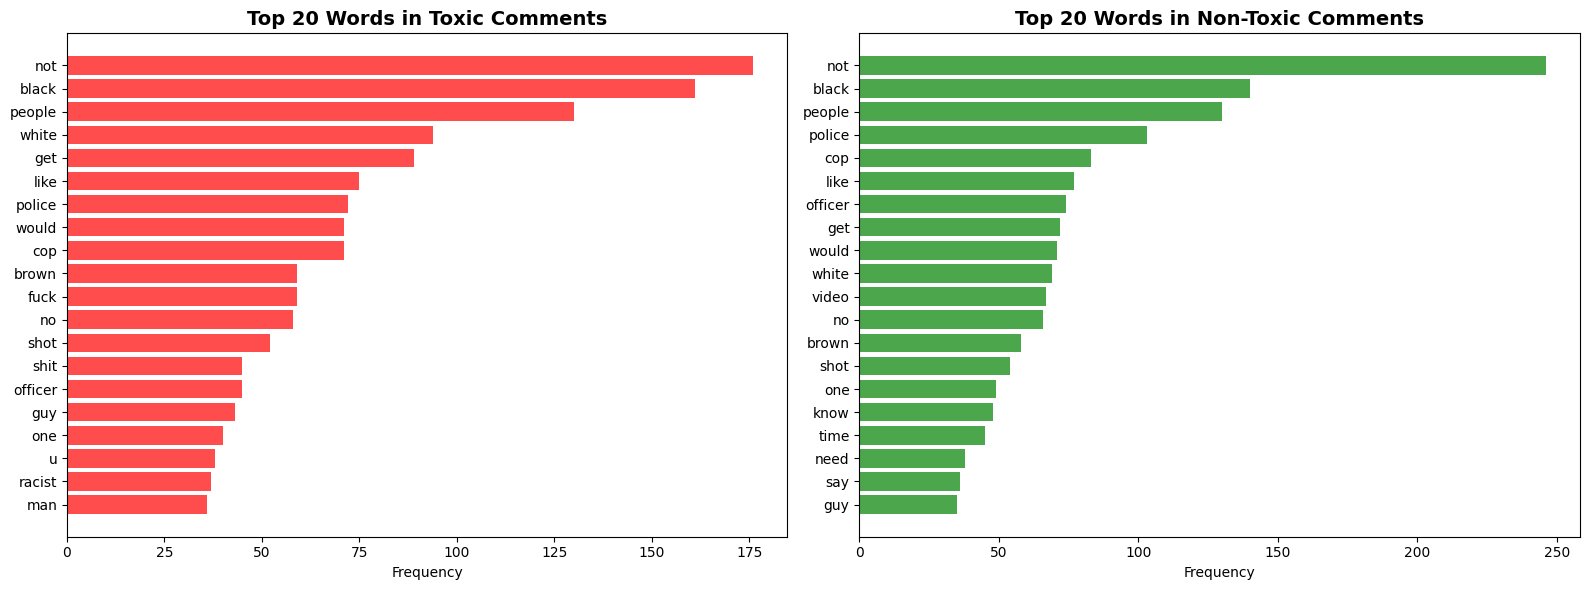

In [11]:
# Visualize top words
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Toxic words
toxic_top20 = dict(toxic_freq.most_common(20))
axes[0].barh(list(toxic_top20.keys()), list(toxic_top20.values()), color='red', alpha=0.7)
axes[0].set_title('Top 20 Words in Toxic Comments', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Frequency')
axes[0].invert_yaxis()

# Non-toxic words
non_toxic_top20 = dict(non_toxic_freq.most_common(20))
axes[1].barh(list(non_toxic_top20.keys()), list(non_toxic_top20.values()), color='green', alpha=0.7)
axes[1].set_title('Top 20 Words in Non-Toxic Comments', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Frequency')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 7. TF-IDF Vectorization

In [12]:
# Create TF-IDF features
print("Creating TF-IDF features...")

# TF-IDF with unigrams
tfidf_vectorizer_unigram = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 1),
    min_df=2,
    max_df=0.9
)

# TF-IDF with unigrams and bigrams
tfidf_vectorizer_bigram = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.9
)

# Fit and transform
X_tfidf_unigram = tfidf_vectorizer_unigram.fit_transform(df['text_cleaned'])
X_tfidf_bigram = tfidf_vectorizer_bigram.fit_transform(df['text_cleaned'])

print(f"✅ TF-IDF Unigram shape: {X_tfidf_unigram.shape}")
print(f"✅ TF-IDF Bigram shape: {X_tfidf_bigram.shape}")

Creating TF-IDF features...
✅ TF-IDF Unigram shape: (1000, 1695)
✅ TF-IDF Bigram shape: (1000, 2601)


In [13]:
# Get feature names and their importance
feature_names = tfidf_vectorizer_bigram.get_feature_names_out()

# Calculate mean TF-IDF scores for toxic vs non-toxic
# Convert pandas Series to numpy array for indexing
toxic_mask = (df['is_toxic'] == 1).values
non_toxic_mask = (df['is_toxic'] == 0).values

toxic_tfidf = X_tfidf_bigram[toxic_mask].mean(axis=0).A1
non_toxic_tfidf = X_tfidf_bigram[non_toxic_mask].mean(axis=0).A1

# Get top features for each class
toxic_top_indices = toxic_tfidf.argsort()[-20:][::-1]
non_toxic_top_indices = non_toxic_tfidf.argsort()[-20:][::-1]

print("\n🔴 Top 20 TF-IDF features in TOXIC comments:")
for idx in toxic_top_indices:
    print(f"  {feature_names[idx]}: {toxic_tfidf[idx]:.4f}")

print("\n🟢 Top 20 TF-IDF features in NON-TOXIC comments:")
for idx in non_toxic_top_indices:
    print(f"  {feature_names[idx]}: {non_toxic_tfidf[idx]:.4f}")


🔴 Top 20 TF-IDF features in TOXIC comments:
  black: 0.0346
  people: 0.0301
  run: 0.0289
  not: 0.0275
  get: 0.0231
  white: 0.0226
  fuck: 0.0219
  would: 0.0190
  police: 0.0181
  like: 0.0178
  idiot: 0.0177
  shit: 0.0171
  cop: 0.0167
  stupid: 0.0167
  shoot: 0.0158
  racist: 0.0154
  guy: 0.0151
  shot: 0.0150
  brown: 0.0148
  no: 0.0146

🟢 Top 20 TF-IDF features in NON-TOXIC comments:
  not: 0.0403
  people: 0.0261
  black: 0.0228
  police: 0.0212
  like: 0.0189
  video: 0.0189
  cop: 0.0173
  get: 0.0167
  no: 0.0150
  peggy: 0.0149
  would: 0.0147
  thank: 0.0145
  officer: 0.0143
  guy: 0.0143
  stefan: 0.0134
  woman: 0.0128
  one: 0.0128
  good: 0.0128
  brown: 0.0127
  white: 0.0125


## 8. N-gram Analysis

In [14]:
# Extract bigrams and trigrams
def get_ngrams(text_list, n=2):
    """Extract n-grams from list of texts"""
    all_ngrams = []
    for text in text_list:
        tokens = text.split()
        text_ngrams = list(ngrams(tokens, n))
        all_ngrams.extend([' '.join(gram) for gram in text_ngrams])
    return Counter(all_ngrams)

# Get bigrams for toxic and non-toxic
toxic_texts = df[df['is_toxic']==1]['text_cleaned'].tolist()
non_toxic_texts = df[df['is_toxic']==0]['text_cleaned'].tolist()

toxic_bigrams = get_ngrams(toxic_texts, n=2)
toxic_trigrams = get_ngrams(toxic_texts, n=3)

print("🔴 Top 15 Bigrams in TOXIC comments:")
for bigram, count in toxic_bigrams.most_common(15):
    print(f"  '{bigram}': {count}")

print("\n🔴 Top 15 Trigrams in TOXIC comments:")
for trigram, count in toxic_trigrams.most_common(15):
    print(f"  '{trigram}': {count}")


🔴 Top 15 Bigrams in TOXIC comments:
  'black people': 33
  'white people': 19
  'mike brown': 16
  'michael brown': 13
  'police officer': 12
  'black life': 10
  'life matter': 10
  'would not': 10
  'let u': 9
  'piece shit': 9
  'black man': 8
  'not get': 8
  'black person': 8
  'got shot': 8
  'get shot': 7

🔴 Top 15 Trigrams in TOXIC comments:
  'black life matter': 7
  'question would still': 5
  'would still reaction': 4
  'black people always': 3
  'officer darren wilson': 3
  'martin luther king': 3
  'luther king jr': 3
  'would love see': 2
  'mike brown father': 2
  'matter grand jury': 2
  'wont get shot': 2
  'let u not': 2
  'racial profiling police': 2
  'black people not': 2
  'people not get': 2


## 9. Save Preprocessed Data

In [15]:
# Save preprocessed dataset
df.to_csv('preprocessed_comments_2.csv', index=False)
print("✅ Preprocessed data saved to 'preprocessed_comments_2.csv'")

# Save vectorizers for later use
import joblib

joblib.dump(tfidf_vectorizer_unigram, 'tfidf_vectorizer_unigram_2.pkl')
joblib.dump(tfidf_vectorizer_bigram, 'tfidf_vectorizer_bigram_2.pkl')
joblib.dump(preprocessor, 'text_preprocessor_2.pkl')

print("✅ Vectorizers and preprocessor saved!")

✅ Preprocessed data saved to 'preprocessed_comments_2.csv'
✅ Vectorizers and preprocessor saved!


## 10. Train-Test Split

In [16]:
# Prepare features and target
X = df['text_cleaned']
target_cols = [
    'IsToxic', 
    'IsAbusive', 
    'IsProvocative', 
    'IsObscene', 
    'IsHatespeech', 
    'IsRacist',
    'IsThreat',
    'IsReligiousHate',
    'IsNationalist',
    'IsSexist'
]
y = df[target_cols]

# Split data - stratify on IsToxic only (most general column)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=df['IsToxic']
)

print("📊 Data Split Summary:")
print(f"Training set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")

# Show distribution for each label
print("\n📊 Label Distribution in Training Set:")
for col in target_cols:
    count = y_train[col].sum()
    pct = (count / len(y_train)) * 100
    print(f"  {col}: {count} ({pct:.2f}%)")

print("\n📊 Label Distribution in Test Set:")
for col in target_cols:
    count = y_test[col].sum()
    pct = (count / len(y_test)) * 100
    print(f"  {col}: {count} ({pct:.2f}%)")

📊 Data Split Summary:
Training set: 800 samples
Test set: 200 samples

📊 Label Distribution in Training Set:
  IsToxic: 370 (46.25%)
  IsAbusive: 282 (35.25%)
  IsProvocative: 133 (16.62%)
  IsObscene: 85 (10.62%)
  IsHatespeech: 114 (14.25%)
  IsRacist: 105 (13.12%)
  IsThreat: 14 (1.75%)
  IsReligiousHate: 7 (0.88%)
  IsNationalist: 6 (0.75%)
  IsSexist: 1 (0.12%)

📊 Label Distribution in Test Set:
  IsToxic: 92 (46.00%)
  IsAbusive: 71 (35.50%)
  IsProvocative: 28 (14.00%)
  IsObscene: 15 (7.50%)
  IsHatespeech: 24 (12.00%)
  IsRacist: 20 (10.00%)
  IsThreat: 7 (3.50%)
  IsReligiousHate: 5 (2.50%)
  IsNationalist: 2 (1.00%)
  IsSexist: 0 (0.00%)


In [18]:
# Save train-test split with all target columns
train_df = pd.DataFrame({'text': X_train})
train_df = train_df.reset_index(drop=True)

# Add all target columns
for col in target_cols:
    train_df[col] = y_train[col].values

test_df = pd.DataFrame({'text': X_test})
test_df = test_df.reset_index(drop=True)

# Add all target columns
for col in target_cols:
    test_df[col] = y_test[col].values

# Save to CSV
train_df.to_csv('train_data_2.csv', index=False)
test_df.to_csv('test_data_2.csv', index=False)

print("\n✅ Train and test sets saved!")
print(f"\nTrain data shape: {train_df.shape}")
print(f"Test data shape: {test_df.shape}")
print(f"\nColumns saved: {list(train_df.columns)}")


✅ Train and test sets saved!

Train data shape: (800, 11)
Test data shape: (200, 11)

Columns saved: ['text', 'IsToxic', 'IsAbusive', 'IsProvocative', 'IsObscene', 'IsHatespeech', 'IsRacist', 'IsThreat', 'IsReligiousHate', 'IsNationalist', 'IsSexist']


## 11. Summary and Next Steps

In [19]:
print("\n" + "="*80)
print("📋 PREPROCESSING SUMMARY")
print("="*80)

print(f"\n✅ Completed Tasks:")
print(f"  1. Text cleaning (URLs, emails, HTML, numbers removed)")
print(f"  2. Contraction expansion")
print(f"  3. Punctuation removal")
print(f"  4. Stopword removal (kept negations)")
print(f"  5. Lemmatization applied")
print(f"  6. TF-IDF vectorization (unigram and bigram)")
print(f"  7. Train-test split (80-20)")

print(f"\n📊 Final Dataset:")
print(f"  - Total samples: {len(df)}")
print(f"  - Average cleaned text length: {df['cleaned_length'].mean():.2f} chars")
print(f"  - Training samples: {len(X_train)}")
print(f"  - Test samples: {len(X_test)}")
print(f"  - TF-IDF features: {X_tfidf_bigram.shape[1]}")

print(f"\n💾 Saved Files:")
print(f"  - preprocessed_comments_2.csv")
print(f"  - train_data_2.csv")
print(f"  - test_data_2.csv")
print(f"  - tfidf_vectorizer_unigram_2.pkl")
print(f"  - tfidf_vectorizer_bigram_2.pkl")
print(f"  - text_preprocessor_2.pkl")

print(f"\n🎯 Ready for Next Phase: MODEL TRAINING")
print("="*80)


📋 PREPROCESSING SUMMARY

✅ Completed Tasks:
  1. Text cleaning (URLs, emails, HTML, numbers removed)
  2. Contraction expansion
  3. Punctuation removal
  4. Stopword removal (kept negations)
  5. Lemmatization applied
  6. TF-IDF vectorization (unigram and bigram)
  7. Train-test split (80-20)

📊 Final Dataset:
  - Total samples: 1000
  - Average cleaned text length: 113.28 chars
  - Training samples: 800
  - Test samples: 200
  - TF-IDF features: 2601

💾 Saved Files:
  - preprocessed_comments_2.csv
  - train_data_2.csv
  - test_data_2.csv
  - tfidf_vectorizer_unigram_2.pkl
  - tfidf_vectorizer_bigram_2.pkl
  - text_preprocessor_2.pkl

🎯 Ready for Next Phase: MODEL TRAINING
